In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv(r"C:\Users\hp\Videos\project\nassau_candy.csv")

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [6]:
df = df[df['Sales'] > 0]
df = df[df['Gross Profit'] != 0]

In [7]:
df['Units'] = df['Units'].fillna(df['Units'].median())

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [10]:
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [11]:
total_sales = df['Sales'].sum()

df['Revenue Contribution %'] = (df['Sales'] / total_sales) * 100

In [12]:
total_profit = df['Gross Profit'].sum()

df['Profit Contribution %'] = (df['Gross Profit'] / total_profit) * 100

In [13]:
top_profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

print(top_profit.head(10))

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64


In [14]:
top_margin = df.groupby('Product Name')['Gross Margin %'].mean().sort_values(ascending=False)

print(top_margin.head(10))

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Name: Gross Margin %, dtype: float64


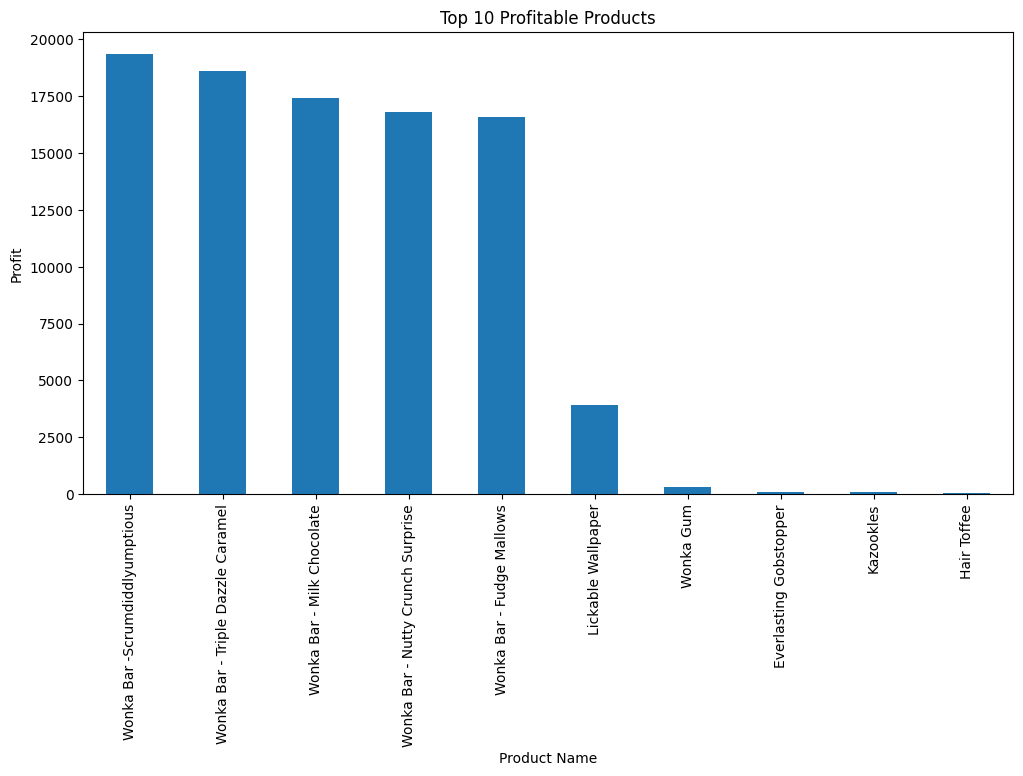

In [15]:
top_profit.head(10).plot(kind='bar', figsize=(12,6))

plt.title("Top 10 Profitable Products")
plt.ylabel("Profit")
plt.show()

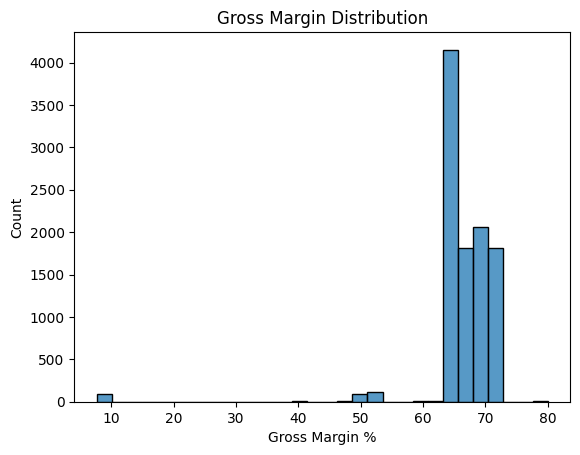

In [16]:
sns.histplot(df['Gross Margin %'], bins=30)

plt.title("Gross Margin Distribution")
plt.show()

In [17]:
division_analysis = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean'
})

print(division_analysis)

               Sales  Gross Profit  Gross Margin %
Division                                          
Chocolate  131692.90      88824.62       67.458162
Other        9663.25       4333.45       37.672457
Sugar         427.48        284.73       57.689001


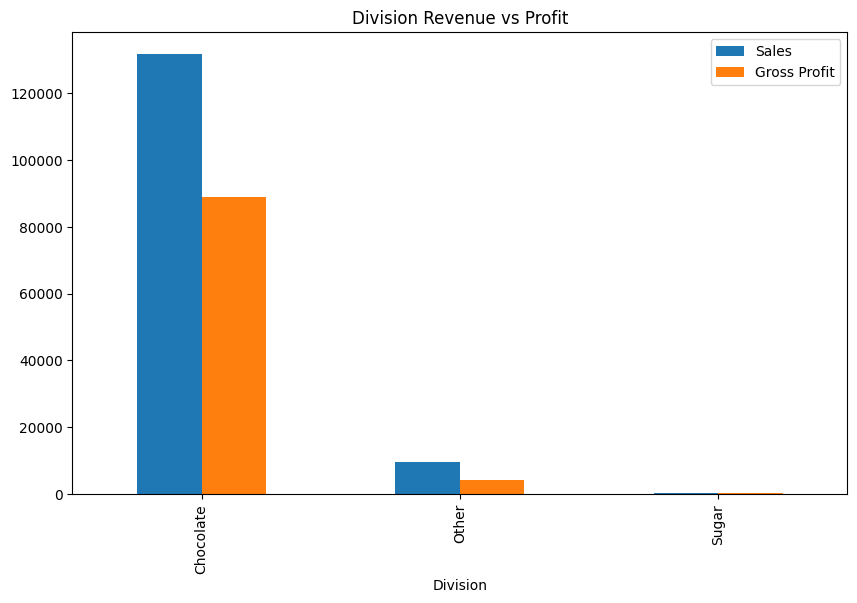

In [18]:
division_analysis[['Sales','Gross Profit']].plot(kind='bar', figsize=(10,6))

plt.title("Division Revenue vs Profit")
plt.show()

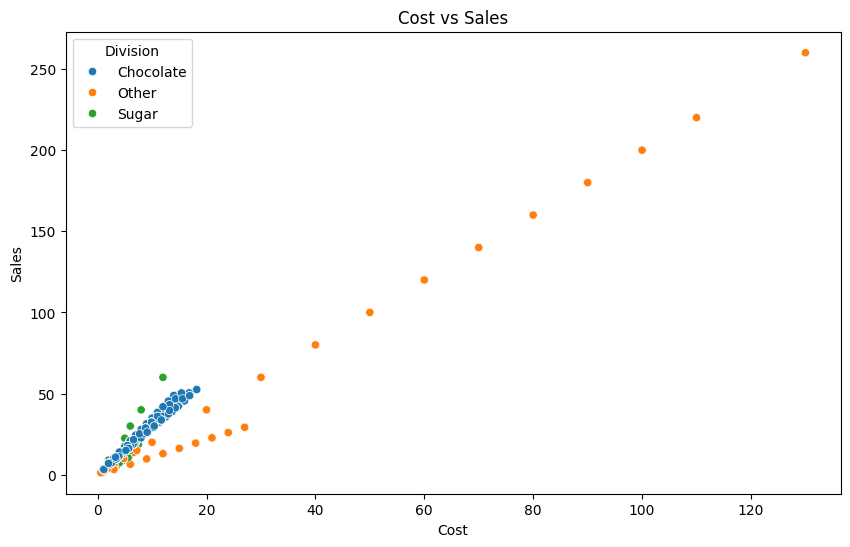

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Cost', y='Sales', hue='Division', data=df)

plt.title("Cost vs Sales")
plt.show()

In [20]:
pareto = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

pareto_df = pareto.reset_index()

pareto_df['Cumulative %'] = pareto_df['Gross Profit'].cumsum() / pareto_df['Gross Profit'].sum() * 100

print(pareto_df.head())

                        Product Name  Gross Profit  Cumulative %
0     Wonka Bar -Scrumdiddlyumptious      19357.50     20.715882
1  Wonka Bar - Triple Dazzle Caramel      18610.20     40.632023
2         Wonka Bar - Milk Chocolate      17443.37     59.299454
3  Wonka Bar - Nutty Crunch Surprise      16819.95     77.299717
4          Wonka Bar - Fudge Mallows      16593.60     95.057747


In [21]:
fig = px.line(
    pareto_df,
    x='Product Name',
    y='Cumulative %',
    title='Pareto Analysis'
)

fig.show()

In [22]:
risk_products = df[
    (df['Sales'] > df['Sales'].median()) &
    (df['Gross Margin %'] < df['Gross Margin %'].median())
]

print(risk_products[['Product Name','Sales','Gross Margin %']])

                            Product Name  Sales  Gross Margin %
4      Wonka Bar - Triple Dazzle Caramel  11.25       65.333333
9             Wonka Bar - Milk Chocolate  13.00       64.923077
15     Wonka Bar - Triple Dazzle Caramel  26.25       65.333333
17     Wonka Bar - Triple Dazzle Caramel  11.25       65.333333
23            Wonka Bar - Milk Chocolate  16.25       64.923077
...                                  ...    ...             ...
10179         Wonka Bar - Milk Chocolate  16.25       64.923077
10182  Wonka Bar - Triple Dazzle Caramel  11.25       65.333333
10185         Wonka Bar - Milk Chocolate  16.25       64.923077
10186  Wonka Bar - Triple Dazzle Caramel  15.00       65.333333
10192  Wonka Bar - Triple Dazzle Caramel  26.25       65.333333

[2444 rows x 3 columns]
